In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd drive/MyDrive/jax-f16-gcas-validation

/content/drive/MyDrive/jax-f16-gcas-validation


In [4]:
!pip install jaxlib
!pip install jax_f16

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.8 MB/s eta 0:00:00


In [5]:
!pip install --upgrade jax[cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


In [6]:
import scipy as sp
from jax.scipy.stats.multivariate_normal import logpdf as multivar_gauss_logpdf


In [7]:
from simulate import *
from f16system import *
import matplotlib.pyplot as plt
import numpy as np

In [8]:
import gc

In [9]:
system = F16System(T=300)
nominal_mean = system.noise_mean
nominal_std = system.noise_std
# p = (nominal_mean, nominal_cov)

In [10]:
def generate_proposal_distributions(p_mean, p_std, num_proposals=1, mean_scale=1, std_scale=1):
    """
    generate proposal distributions by taking the nominal distribution
    parameters and perturbing them by a random value
    """
    qs = [] # proposal distributions
    mask = np.zeros(16) # which components we are going to change for proposal
    mask[3] = 1
    mask[6] = 1
    # create proposal distributions by slightly perturbing the parameters of nominal dist
    for i in range(num_proposals):
        # use mask to only change the noisy features
        q_mean = p_mean + (mean_scale * np.random.uniform(-1, 1, 16) * mask)
        q_std = p_std + (std_scale * np.random.uniform(0, 1, 16) * mask)
        # qs.append(jsp.stats.multivariate_normal(q_mean, system.noise_std))
        qs.append((q_mean, q_std))
    return qs

In [ ]:
# def generate_proposal_distributions_mean(p_mean, p_std, mean_scale=1):
#     """
#     generate proposal distributions by taking the nominal distribution
#     parameters and perturbing them by a random value
#     """
#     qs = [] # proposal distributions
#     mask = np.zeros(16) # which components we are going to change for proposal
#     mask[3] = 1
#     mask[6] = 1
#     # create proposal distributions by slightly perturbing the parameters of nominal dist
#     qs.append((q_mean, q_std))
#     for i in range(num_proposals):
#         # use mask to only change the noisy features
#         q_mean = p_mean + (mean_scale * mask)
#         q_std = p_std + (std_scale * np.random.uniform(0, 1, 16) * mask)
#         # qs.append(jsp.stats.multivariate_normal(q_mean, system.noise_std))
#         qs.append((q_mean, q_std))
#     return qs

In [17]:
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.0508633e-05,
#         0.0000000e+00,  0.0000000e+00,  2.1600521e-03,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.0508633e-06,
#         0.0000000e+00,  0.0000000e+00,  2.1600521e-04,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5e-03, 1.e-10, 1.e-10, 5e-03, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 1e-4,
        0.0000000e+00,  0.0000000e+00,  1e-4,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.e-3, 1.e-10, 1.e-10, 5.e-3, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]

In [18]:
print(proposal)

[(array([0.    , 0.    , 0.    , 0.0001, 0.    , 0.    , 0.0001, 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ]), array([1.e-10, 1.e-10, 1.e-10, 5.e-03, 1.e-10, 1.e-10, 5.e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]


In [ ]:
qs = generate_proposal_distributions(proposal[0][0], proposal[0][1], num_proposals=5, mean_scale=0, std_scale=1e-3)
# qs = generate_proposal_distributions(nominal_mean, nominal_std, num_proposals=70, mean_scale=5e-2, std_scale=1e-4)
# qs = generate_proposal_distributions(nominal_mean, nominal_std, num_proposals=50, mean_scale=1e-3, std_scale=0)
# x = [q[1][3] for q in qs]
# y = [q[1][6] for q in qs]
# plt.scatter(x, y)

In [ ]:
print(qs)
qs_plus = qs + proposal

[(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 5.98355033e-03,
       1.00000000e-10, 1.00000000e-10, 5.35274660e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10])), (array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 6.19699061e-03,
       1.00000000e-10, 1.00000000e-10, 5.85179607e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10])), (array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 5.33818259e-03,
       1.00000000e-10, 1.00000000e-10, 5.92544535e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.0000

In [11]:
def imp_sampl_fail_est(p, qs, num_rollouts, DMMIS=False):
    q_systems = []
    for q in qs:
        q_system = F16System(T=300, prop_noise_mean=q[0], prop_noise_std=q[1])
        q_systems.append(q_system)
    rollouts = []
    ws = []
    weighted_sum = 0
    rollout_cnt = 0
    estimates = []
    for j in tqdm(range(num_rollouts), desc="Running Rollouts"):
        for q in q_systems:
            rollout_cnt += 1
            rollout = q.rollout_min_altitude_and_loglik()
            gc.collect()
            rollouts.append(rollout)
            traj = rollout[2][2].reshape(-1, 16)
            p_i = gaussian_log_pdf_traj(traj, p.noise_mean, p.noise_cov)
            q_i = gaussian_log_pdf_traj(traj, q.sensor.mean, q.sensor.cov)
            # ws.append(np.exp(p_i - q_i))
            w_i = np.exp(p_i - q_i)
            if rollout[0] < CRASH_ALT:
                print("\nFound failure!")
                print(p_i)
                print(q_i)
                print("Weight is", w_i.item())
                weighted_sum += w_i.item()
            est = weighted_sum / rollout_cnt
            print("\nWeighted sum:", weighted_sum)
            print("\nFailure probability estimate after %d rollouts: %f" % (rollout_cnt, est))
            estimates.append(est)
        jax.clear_caches()
    return estimates

In [19]:
# estimates = imp_sampl_fail_est(system, qs, num_rollouts=50)
estimates = imp_sampl_fail_est(system, proposal, num_rollouts=100)

Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:31<52:20, 31.72s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:46<35:31, 21.75s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [24:01<00:29, 14.51s/it]


Weighted sum: 2.2659952342510223

Failure probability estimate after 99 rollouts: 0.022889


Running Rollouts:  99%|█████████▉| 99/100 [24:15<00:14, 14.43s/it]


Weighted sum: 2.2659952342510223

Failure probability estimate after 100 rollouts: 0.022660


Running Rollouts: 100%|██████████| 100/100 [24:29<00:00, 14.70s/it]


In [12]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 1e-5,
        0.0000000e+00,  0.0000000e+00,  1e-5,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.e-3, 1.e-10, 1.e-10, 5.e-3, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]

In [21]:
estimates_mean1e_5 = imp_sampl_fail_est(system, proposal, num_rollouts=100)

Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:13<22:09, 13.43s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:27<22:25, 13.73s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [23:27<00:29, 14.69s/it]


Weighted sum: 3.0140587091445923

Failure probability estimate after 99 rollouts: 0.030445


Running Rollouts:  99%|█████████▉| 99/100 [23:42<00:14, 14.65s/it]


Weighted sum: 3.0140587091445923

Failure probability estimate after 100 rollouts: 0.030141


Running Rollouts: 100%|██████████| 100/100 [23:56<00:00, 14.36s/it]


Text(0, 0.5, 'Estimated Failure Probability')

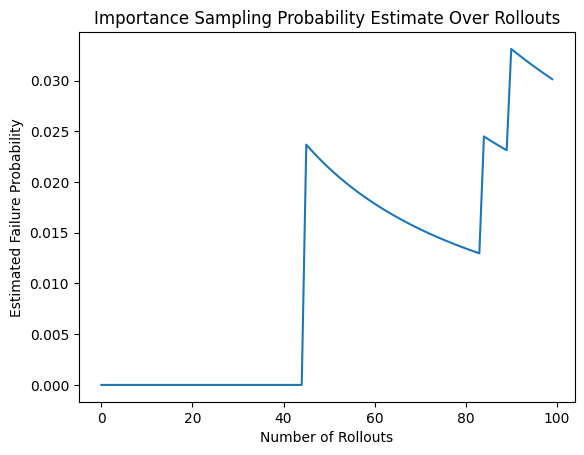

In [22]:
plt.plot(np.arange(len(estimates_mean1e_5)), estimates_mean1e_5)
plt.title("Importance Sampling Probability Estimate Over Rollouts")
plt.xlabel("Number of Rollouts")
plt.ylabel("Estimated Failure Probability")

In [24]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 1e-3,
        0.0000000e+00,  0.0000000e+00,  1e-3,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.e-3, 1.e-10, 1.e-10, 5.e-3, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]

In [25]:
estimates_mean1e_3 = imp_sampl_fail_est(system, proposal, num_rollouts=100)

Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:13<22:53, 13.87s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:27<22:51, 14.00s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [23:19<00:29, 14.52s/it]


Weighted sum: 9.545815106237754e-05

Failure probability estimate after 99 rollouts: 0.000001


Running Rollouts:  99%|█████████▉| 99/100 [23:34<00:14, 14.44s/it]


Weighted sum: 9.545815106237754e-05

Failure probability estimate after 100 rollouts: 0.000001


Running Rollouts: 100%|██████████| 100/100 [23:48<00:00, 14.28s/it]


In [ ]:
# prob = [estimates[i] / (i+1) for i in range(len(estimates))]    # accidentally

Text(0, 0.5, 'Probability estimate')

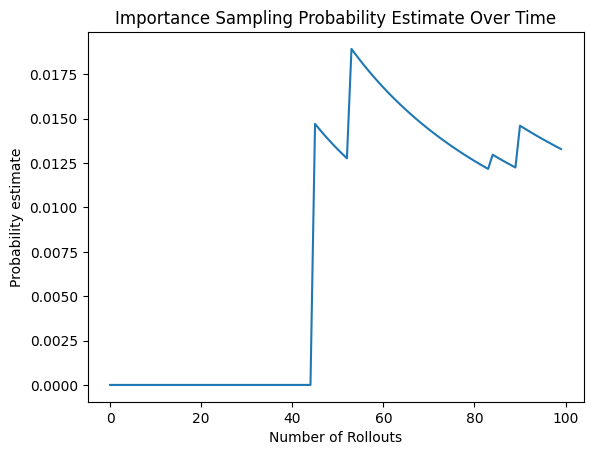

In [ ]:
plt.plot(np.arange(len(estimates)), estimates)
plt.title("Importance Sampling Probability Estimate Over Time")
plt.xlabel("Number of Rollouts")
plt.ylabel("Probability estimate")

In [ ]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.2e-03, 1.e-10, 1.e-10, 5.2e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
estimates = imp_sampl_fail_est(system, proposal, num_rollouts=100)


Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:15<25:32, 15.48s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:30<24:32, 15.03s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [25:34<00:32, 16.14s/it]


Weighted sum: 2.8786394596099854

Failure probability estimate after 99 rollouts: 0.029077


Running Rollouts:  99%|█████████▉| 99/100 [25:50<00:16, 16.10s/it]


Weighted sum: 2.8786394596099854

Failure probability estimate after 100 rollouts: 0.028786


Running Rollouts: 100%|██████████| 100/100 [26:06<00:00, 15.66s/it]


In [ ]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.1e-03, 1.e-10, 1.e-10, 5.1e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
estimates51 = imp_sampl_fail_est(system, proposal, num_rollouts=100)

Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:15<25:25, 15.41s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:30<25:05, 15.36s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [25:21<00:32, 16.18s/it]


Weighted sum: 4.245431303977966

Failure probability estimate after 99 rollouts: 0.042883


Running Rollouts:  99%|█████████▉| 99/100 [25:36<00:16, 16.06s/it]


Weighted sum: 4.245431303977966

Failure probability estimate after 100 rollouts: 0.042454


Running Rollouts: 100%|██████████| 100/100 [25:52<00:00, 15.53s/it]


In [ ]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.4e-03, 1.e-10, 1.e-10, 5.4e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
estimates54 = imp_sampl_fail_est(system, proposal, num_rollouts=100)

Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:14<24:40, 14.95s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:30<24:46, 15.17s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [25:25<00:32, 16.05s/it]


Weighted sum: 0.15727658849209547

Failure probability estimate after 99 rollouts: 0.001589


Running Rollouts:  99%|█████████▉| 99/100 [25:41<00:16, 16.06s/it]


Weighted sum: 0.15727658849209547

Failure probability estimate after 100 rollouts: 0.001573


Running Rollouts: 100%|██████████| 100/100 [25:58<00:00, 15.58s/it]


In [ ]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.2e-03, 1.e-10, 1.e-10, 5.2e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
estimates = imp_sampl_fail_est(system, qs, num_rollouts=100)